# QF 627 Programming and Computational Finance
## Problem Set `5` | `Questions`

> Hi Team! 👋

> The current problem set has two main parts. Questions 1 through 7 are scenario-based, giving you a taste of day-to-day operations as a buy-side Quant in the field. Questions 8 through 12 will help you explore a technical indicator for detecting momentum signals—namely, the Moving Average Convergence Divergence (MACD).

> As always, these questions have been carefully designed to guide your optimal learning. While you read and answer the questions, you’ll be able to feel my affection for you all 🙌

> Enjoy 🤗

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 Questions 1 through 7 are based on the following scenario. After reading it, please respond to the associated sub-questions.

> Suppose that you've been appointed as a Quantitative Researcher in the process-driven investing division of a leading hedge fund. As part of your onboarding challenge, you are handed data (`alphas.csv`) for three experimental trading models, codenamed Alphas A, B, and C. These models, each initiated with a capital of 100K, demonstrate nearly identical Sharpe ratios across a span of 1120 trading days. Intrigued by this uniformity yet aware of the Sharpe ratio's shortcomings, you embark on a journey to dissect the Alphas' performance through a multifaceted quantitative lens.

### <font color = blue> 👉 Question 1</font>. Sharpe Ratio Diagnostics:

- Given the daily return series for Alphas A, B, and C:

- Derive the annualized Sharpe ratio for each Alpha, with the industry-standard assumption of 252 trading days per annum. In light of these findings, how might you reconsider the perceived risk-adjusted returns of these models?

### <font color = red> Answer 1 is presented in the cell below: </font>

In [3]:
df =\
(
    pd.read_csv("alphas.csv",
                index_col = 0,
                parse_dates = True)
)

In [4]:
df_rets =\
np.log(df / df.shift(1))

In [5]:
sharpes =\
df_rets.mean() / df_rets.std() * np.sqrt(252)

In [6]:
sharpes

Alphas A   -0.155830
Alphas B   -0.165371
Alphas C   -0.160252
dtype: float64

### <font color = blue> 👉 Question 2</font>. Trajectory of Cumulative Returns:
    
- Visualize and compare the cumulative returns of each Alpha, using both lets-plot and matplotlib libraries.

### <font color = red> Answer 2 is presented in the cell below: </font>

In [7]:
df_rets =\
(
    df_rets.fillna(0).cumsum().apply(np.exp)
)

<Axes: ylabel='Stock Price'>

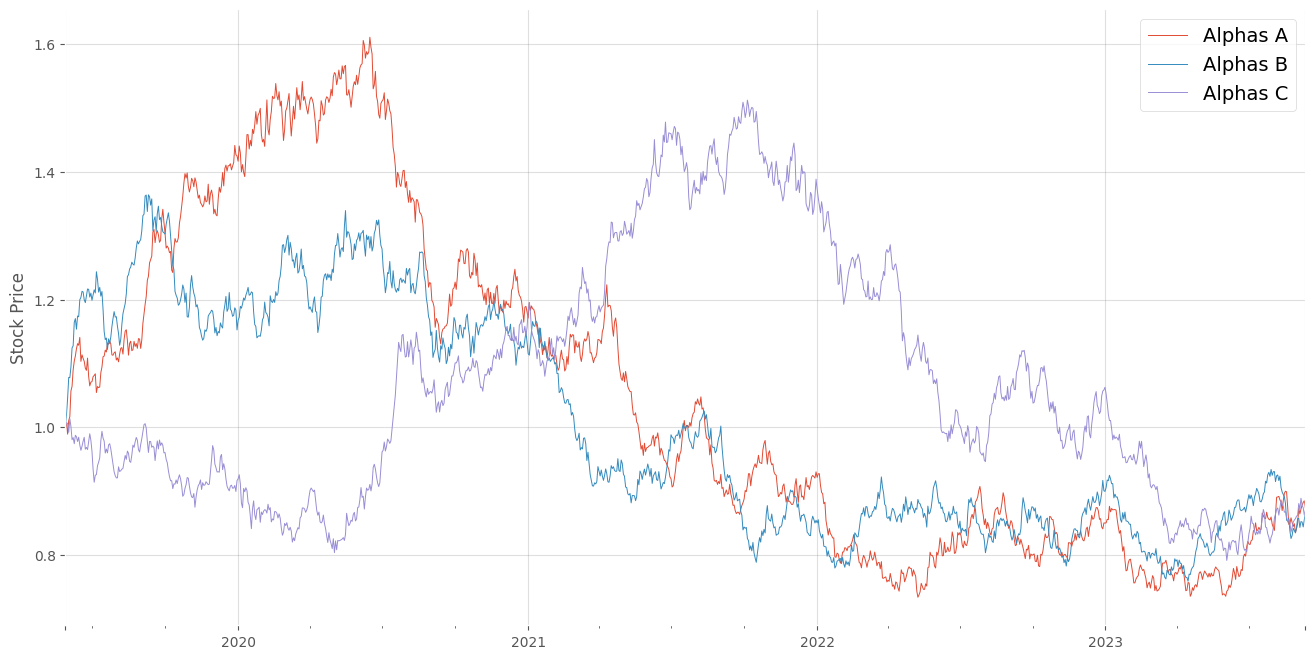

In [8]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    df_rets
    .plot(ax = sub,
          lw = 0.70)
)


In [9]:
from lets_plot import *
LetsPlot.setup_html()

In [10]:
df_rets.reset_index().melt(id_vars = 'index')

,index,variable,value
0,2019-05-28,Alphas A,1.000000
1,2019-05-29,Alphas A,1.005624
2,2019-05-30,Alphas A,0.989036
3,2019-05-31,Alphas A,1.010464
4,2019-06-03,Alphas A,1.016492
...,...,...,...
3358,2023-09-06,Alphas C,0.888647
3359,2023-09-07,Alphas C,0.877824
3360,2023-09-08,Alphas C,0.873915
3361,2023-09-11,Alphas C,0.862415


In [11]:
df_melt =\
(
    df_rets.reset_index().melt(id_vars = "index")
)

In [12]:
p =\
(
    ggplot(df_melt, aes(x = "index", y='value', color='variable')) +
    geom_line(size=0.5) +
    labs(title='Cumulative Return of Different Alphas',
         x='Date',
         y='Cumulative Return') +
    theme(legend_position = 'right') +
    ggsize(1200,500)

)

p

### <font color = blue> 👉 Question 3</font>. Cumulative Returns Over a 1120-Day Horizon:

- Extrapolate the cumulative returns for each Alpha over this period.
  
- When evaluating based on the Compound Annual Growth Rate (CAGR), how do these Alphas stack up against one another?

### <font color = red> Answer 3 is presented in the cell below: </font>

In [13]:
df.shape

(1121, 3)

In [14]:
df[df.columns[0]].count()

np.int64(1121)

In [15]:
(df.iloc[-1] / df.iloc[0]) ** (252 / (df[df.columns[0]].count() - 1)) - 1

Alphas A   -0.030094
Alphas B   -0.031762
Alphas C   -0.030805
dtype: float64

In [16]:
cagrs =\
(
    (df.iloc[-1] / df.iloc[0]) ** (252 / (df[df.columns[0]].count() - 1)) - 1
)

### <font color = blue> 👉 Question 4</font>. Maximum Draw-down (MDD):

- Assess the Maximum Drawdown (MDD) for each model within this time frame.

- Based on this assessment, which Alpha appears best equipped to withstand market downturns?

### <font color = red> Answer 4 is presented in the cell below: </font>

In [17]:
daily_drawdown =\
(
    df_rets / df_rets.cummax() - 1
)

In [18]:
MDD = daily_drawdown.min()

In [19]:
MDD

Alphas A   -0.544602
Alphas B   -0.443717
Alphas C   -0.476758
dtype: float64

### <font color = blue> 👉 Question 5</font>. Examining Drawdown Duration:

- Analyze the longest drawdown durations for each strategy.

- Which of the Alphas seems to have the quickest recovery mechanism following a significant drawdown?

### <font color = red> Answer 5 is presented in the cell below: </font>

In [20]:
max_gross =df_rets.cummax()

In [21]:
max_gross.mode().iloc[0]

Alphas A    1.610776
Alphas B    1.363998
Alphas C    1.512298
Name: 0, dtype: float64

In [22]:
longest_drawdown =\
    [(max_gross[alpha] == mode).sum() for alpha, mode in max_gross.mode().iloc[0].items()]

In [23]:
longest_drawdown

[np.int64(846), np.int64(1046), np.int64(505)]

In [24]:
df.columns

Index(['Alphas A', 'Alphas B', 'Alphas C'], dtype='object')

In [25]:
LDD =\
pd.Series(longest_drawdown,
          index = df.columns)

In [26]:
LDD

Alphas A     846
Alphas B    1046
Alphas C     505
dtype: int64

### <font color = blue> 👉 Question 6</font>. Comprehensive Assessment of Strategy Performance:

- By synthesizing data from metrics such as the Sharpe ratio, cumulative returns trajectory, MDD, and drawdown duration, provide a well-rounded analysis of the three Alphas. 

- Rank and justify your recommendations based on your quantitative insights.

### <font color = red> Answer 6 is presented in the cell below: </font>

In [27]:
metrics =\
pd.DataFrame({"Sharpe": sharpes,
              "CAGR": cagrs,
              "MDD": MDD,
              "LDD (days)": LDD,})

In [28]:
metrics

,Sharpe,CAGR,MDD,LDD (days)
Alphas A,-0.155830,-0.030094,-0.544602,846
Alphas B,-0.165371,-0.031762,-0.443717,1046
Alphas C,-0.160252,-0.030805,-0.476758,505


In [29]:
metrics['Sharpe'] * metrics['CAGR'] / (-metrics['MDD'] * metrics['LDD (days)']/252)

Alphas A    0.002565
Alphas B    0.002852
Alphas C    0.005167
dtype: float64

### <font color = blue> 👉 Question 7</font>. Reflecting on the Sharpe Ratio:

- Given the observed disparities in cumulative returns and MDD among the Alphas, even with similar Sharpe ratios, evaluate the effectiveness of relying solely on the Sharpe ratio.

- Can you propose additional or refined metrics to differentiate between Alphas with matching Sharpe values but varying performances in other critical areas?

### <font color = red> Answer 7 is presented in the cell below: </font>

Area (trapz, in drawdown-days): {'Alphas A': np.float64(350.89106148131475), 'Alphas B': np.float64(287.7959694935005), 'Alphas C': np.float64(192.71123178211025)}
Area (Riemann sum, in drawdown-days): {'Alphas A': np.float64(351.1200701645538), 'Alphas B': np.float64(287.9783882559922), 'Alphas C': np.float64(192.92353286025667)}
Area per year (trapz): {'Alphas A': np.float64(1.3924248471480745), 'Alphas B': np.float64(1.1420474979900812), 'Alphas C': np.float64(0.7647271102464692)}


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_6761/1980685941.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  areas_trapz[col] = np.trapz(-series, dx=1)


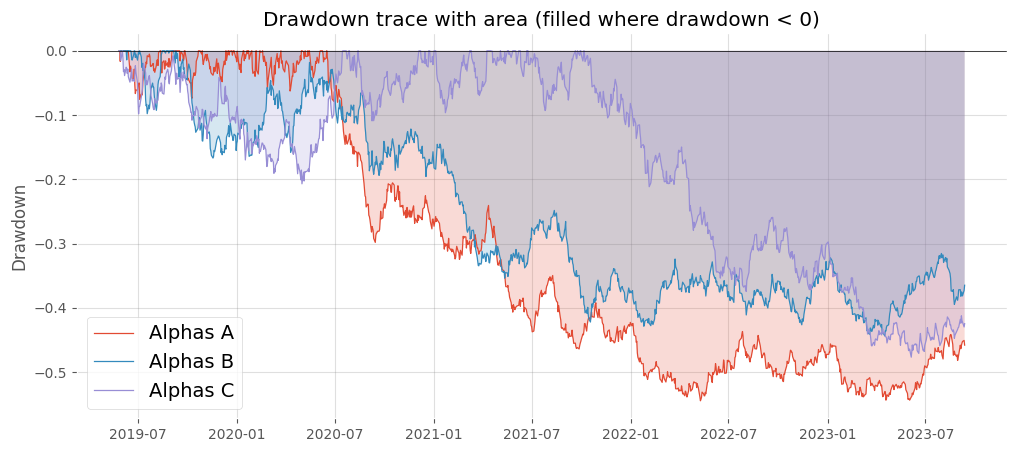

In [31]:
dd = daily_drawdown
areas_trapz = {}
areas_sum = {}
for col in dd.columns:
    series = dd[col].values
    # trapezoidal integration (units: drawdown-days)
    areas_trapz[col] = np.trapz(-series, dx=1)
    # simple Riemann sum (also drawdown-days)
    areas_sum[col] = (-np.clip(series, a_min=None, a_max=0)).sum()

print("Area (trapz, in drawdown-days):", areas_trapz)
print("Area (Riemann sum, in drawdown-days):", areas_sum)

# normalize to per-year by dividing by 252 trading days (optional)
areas_trapz_per_year = {k: v/252 for k, v in areas_trapz.items()}
print("Area per year (trapz):", areas_trapz_per_year)

# plot with filled area between trace and x-axis
plt.figure(figsize=(12,5))
for col in dd.columns:
    plt.plot(dd.index, dd[col], lw=0.9, label=col)
    plt.fill_between(dd.index, dd[col], 0, where=dd[col]<0, alpha=0.2)
plt.axhline(0, color='k', lw=0.5)
plt.ylabel('Drawdown')
plt.title('Drawdown trace with area (filled where drawdown < 0)')
plt.legend()
plt.show()

In [46]:
dd_area =\
(
    pd.Series(areas_trapz_per_year)
)

In [47]:
sharpes - dd_area

Alphas A   -1.548255
Alphas B   -1.307418
Alphas C   -0.924979
dtype: float64

## 👇 Questions 8 to 12 ask you to build, execute, and backtest a strategy based on one kind of momentum strategy called the `Moving Average Convergence Divergence` (MACD) crossover.

### <font color = blue> 👉 Question 8</font>. Let’s take a look at Apple (AAPL) as our security of interest, over the three-year period of 2015 through 2017.

#### Moving Average Convergence Divergence (`MACD`) is a lagging, trend-following momentum indicator reflecting the relationship between two moving averages of stock prices.

#### The strategy utilizes two indicators, the MACD and the MACD signal line:

- The MACD is defined as the `difference` between the `12`-day ***exponential*** moving average and the `26`-day exponential moving average.
- The MACD `signal line` is then defined as the `9`-day ***exponential*** moving average of the MACD.

### <font color = green> NOTE: The MACD crossover strategy is defined as:

- A `bullish` crossover arises when the MACD line turns `upward and crosses` beyond the MACD signal line.
- A `bearish` crossover arises when the MACD line turns `downward and crosses` under the MACD signal line.

### Visualize your buy and sell positions.

### Below are the lines of code that lead to an answer:

In [146]:
aapl = yf.download("AAPL", 
            start="2014-01-01", 
            end="2017-12-31")['Close']

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_6761/1407164631.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL",
[*********************100%***********************]  1 of 1 completed


In [147]:
aapl.shape

(1007, 1)

### <font color = red> Answer 8 is presented in the cell below: </font>

In [148]:
aapl['MACD'] = aapl.ewm(span=12,min_periods=12).mean() - aapl.ewm(span=26,min_periods=26).mean()
aapl['Signal_line'] = aapl['MACD'].ewm(span=9,min_periods=9).mean()
aapl = aapl.dropna()

In [149]:
aapl['signal'] =\
(
    np.where(aapl['MACD'] > aapl['Signal_line'], 1, -1)
)

aapl['trade'] = aapl['signal'].diff()

#  fill first day
aapl.at[aapl.index[0], 'trade'] = aapl.at[aapl.index[0], 'signal'] * 2

In [150]:
aapl_melt = aapl.reset_index()
aapl_melt = aapl_melt.rename(columns={'index': 'Date'})

p = (
    ggplot(aapl_melt, aes(x='Date')) +
    geom_line(aes(y='AAPL'), color='grey', size=0.7) +
    geom_point(aes(y='AAPL'), data=aapl_melt[aapl_melt['trade']==2.0], color='green', size=3) +
    geom_point(aes(y='AAPL'), data=aapl_melt[aapl_melt['trade']==-2.0], color='red', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)

p



In [151]:
q = (
    ggplot(aapl_melt, aes(x='Date')) +
    geom_line(aes(y='MACD'), color='blue') +
    geom_line(aes(y='Signal_line'), color='orange') +
    ggsize(1200, 500)
)
q

### <font color = blue> 👉 Question 9</font>. Let’s suppose that you started from a $100,000 capital base for the given security.

### Given a $5 fixed commission fee per trade, how much in cumulative returns could you have had as a result of the MACD crossover strategy?

### Below are the lines of code that lead to an answer:

In [160]:
initial_cap = 100_000

In [161]:
aapl = aapl[aapl.index >= '2015-01-01']

In [162]:
aapl['passive_ret'] = np.log(aapl['AAPL'] / aapl['AAPL'].shift(1))
aapl['strategy_ret'] = aapl['passive_ret'] * aapl['signal'].shift(1)
aapl = aapl.fillna(0)

In [163]:

cap = initial_cap

for date, row in aapl.iterrows():
    cap *= np.exp(row['strategy_ret'])
    if row['trade'] == 2.0 or row['trade'] == -2.0:
        cap -= 5

print(cap)

207436.14398297993


In [170]:
gross_ret = (cap / initial_cap) - 1
cagr = (cap / initial_cap) ** (252 / aapl.shape[0]) - 1

### <font color = red> Answer 9 </font>

    The answer is ____________ % .

In [171]:
f"    The answer is {gross_ret*100:.2f} %  and {cagr*100:.2f} % ."

'    The answer is 107.44 %  and 27.58 % .'

### <font color = blue> 👉 Question 10</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

In [174]:
cumrets = aapl['strategy_ret'].cumsum().apply(np.exp)

In [187]:
max_gross = cumrets.cummax()
daily_dd = cumrets / max_gross - 1

In [188]:
max_drawdown = daily_dd.min()

In [195]:
# take date column out and cumsum for periods
dd_reset = daily_dd.reset_index()
dd_reset['period'] = (dd_reset['strategy_ret'] == 0).cumsum()
# find nodes with 0 value i.e. highpoints
dd_nonzero = dd_reset[dd_reset['strategy_ret'] != 0]
# aggregate by period
period_stats = dd_nonzero.groupby('period').agg(
    start_date = ('Date', 'min'),
    end_date = ('Date', 'max'),
    avg_dd = ('strategy_ret', 'mean'),
    max_dd = ('strategy_ret', 'min'),
    duration=('strategy_ret', 'count')
).sort_values(by='avg_dd',ascending=True)


In [199]:
dd_nonzero.head(10)

,Date,strategy_ret,period
2,2015-01-06,-0.000094,2
3,2015-01-07,-0.013921,2
4,2015-01-08,-0.050407,2
5,2015-01-09,-0.051424,2
6,2015-01-12,-0.027460,2
7,2015-01-13,-0.036019,2
8,2015-01-14,-0.032331,2
9,2015-01-15,-0.005336,2
11,2015-01-20,-0.025110,3
12,2015-01-21,-0.032496,3


In [197]:
period_stats.head(6)

,start_date,end_date,avg_dd,max_dd,duration
period,,,,,
15,2015-03-12,2016-01-05,-0.094411,-0.176032,207
50,2016-09-12,2017-06-08,-0.082749,-0.174035,187
18,2016-01-22,2016-03-21,-0.072504,-0.125381,41
67,2017-08-16,2017-09-22,-0.044607,-0.066967,27
76,2017-11-09,2017-12-29,-0.037956,-0.089113,35
23,2016-04-05,2016-04-26,-0.035226,-0.071170,16


### <font color = red> Answer 10 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

In [201]:
worst_periods = period_stats.head(5).reset_index(drop=True)

for i, row in worst_periods.iterrows():
    rank = i + 1
    net_dd = row['max_dd'] * 100  # convert to %
    duration = row['duration']
    if rank == 1:
        label = "The Worst drawdown period"
    else:
        label = f"The {rank}th worst drawdown period"
    
    print(f"{label:<30}: Net drawdown {net_dd:.2f} % | Duration {duration} Trading Days")


The Worst drawdown period     : Net drawdown -17.60 % | Duration 207 Trading Days
The 2th worst drawdown period : Net drawdown -17.40 % | Duration 187 Trading Days
The 3th worst drawdown period : Net drawdown -12.54 % | Duration 41 Trading Days
The 4th worst drawdown period : Net drawdown -6.70 % | Duration 27 Trading Days
The 5th worst drawdown period : Net drawdown -8.91 % | Duration 35 Trading Days


### <font color = blue> 👉 Question 11</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

<Axes: xlabel='Date'>

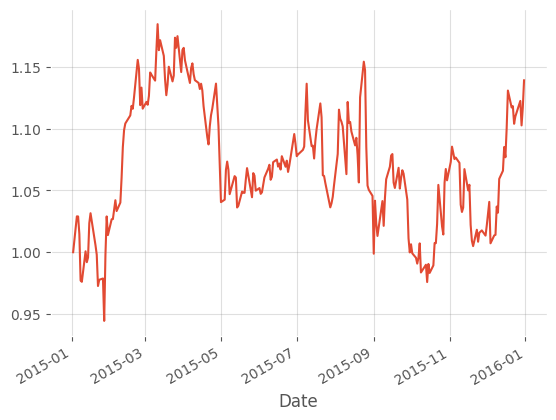

In [202]:
cumrets.loc[:'2015-12-31'].plot()

In [203]:
aapl_15 = cumrets.loc[:'2015-12-31']
aapl_16 = cumrets.loc['2015-12-31':'2016-12-31']
aapl_17 = cumrets.loc['2016-12-31':'2017-12-31']


aapl_15_cagr = ((aapl_15.iloc[-1] / aapl_15.iloc[0]) ** (252 / aapl_15.shape[0]) -1)
aapl_16_cagr = ((aapl_16.iloc[-1] / aapl_16.iloc[0]) ** (252 / aapl_16.shape[0]) -1)
aapl_17_cagr = ((aapl_17.iloc[-1] / aapl_17.iloc[0]) ** (252 / aapl_17.shape[0]) -1)

ave_cagr = (aapl_15_cagr + aapl_16_cagr + aapl_17_cagr)/3 * 100

In [204]:
print(f"Average CAGR over 2015, 2016, 2017: {ave_cagr:.2f}%")
print(f"2015: {aapl_15_cagr*100:.2f}%, \n2016: {aapl_16_cagr*100:.2f}%, \n2017: {aapl_17_cagr*100:.2f}%")

Average CAGR over 2015, 2016, 2017: 27.93%
2015: 13.90%, 
2016: 39.74%, 
2017: 30.14%


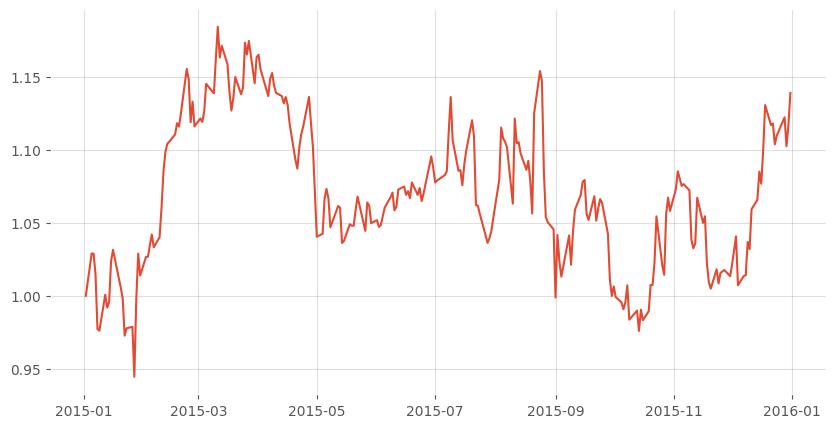

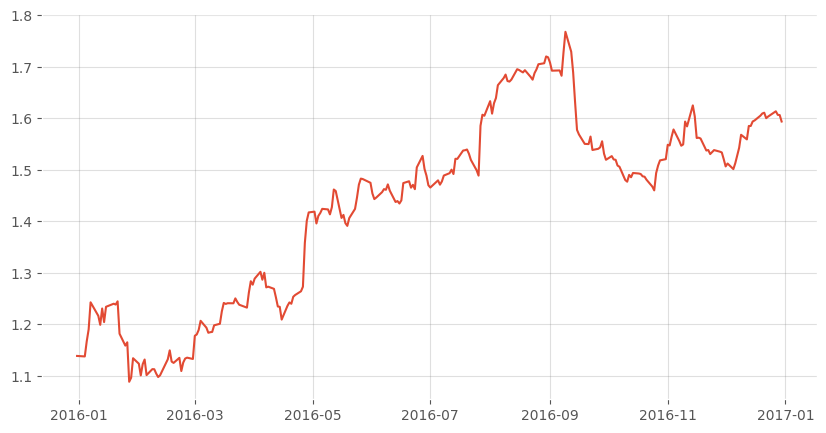

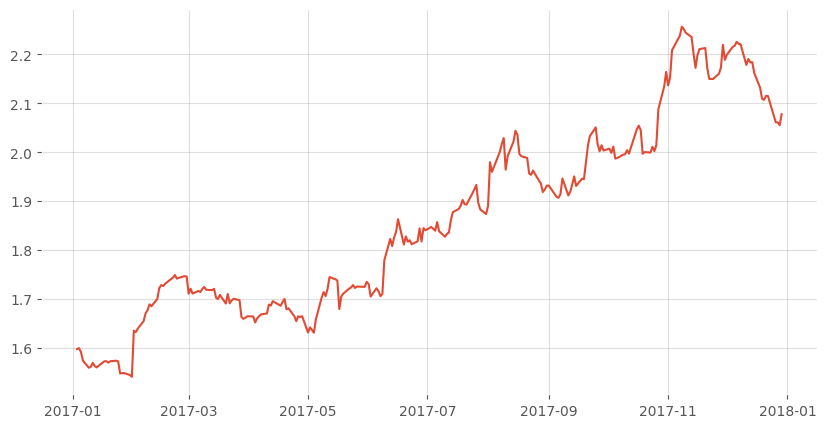

In [206]:
for a in [aapl_15, aapl_16, aapl_17]:
    plt.figure(figsize=(10,5))
    plt.plot(a.index, a.values)

### <font color = red> Answer 11 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

In [207]:
print(f"Below average year(s): {[year for year, cagr in zip([2015, 2016, 2017], 
                                                      [aapl_15_cagr, aapl_16_cagr, aapl_17_cagr]) if cagr*100 < ave_cagr]}")
print(f"Above average year(s): {[year for year, cagr in zip([2015, 2016, 2017], 
                                                      [aapl_15_cagr, aapl_16_cagr, aapl_17_cagr]) if cagr*100 > ave_cagr]}")

Below average year(s): [2015]
Above average year(s): [2016, 2017]


###  <font color = blue> 👉 Question 12. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

In [209]:
sharpe = aapl.strategy_ret.mean() / aapl.strategy_ret.std() * np.sqrt(252)

### <font color = red> Answer 12 </font>
    
    Sharpe ratio: __________
    

In [210]:
f"Sharpe ratio: {sharpe:1f}"

'Sharpe ratio: 1.068836'

### <font color="green">"💯 Thank you for putting your efforts into the exercise problem sets 😊"</font>